# 16. 前沿架构：MoE 混合专家 —— Router 与 top-k 手搓

大模型要更大但推理要更快？**MoE（Mixture of Experts）**：把 FFN 换成 N 个专家（每个都是独立小 FFN），
一个 **Router（门控）** 给每个 token 选 top-k 个专家，**稀疏激活**：总参数量大、每次只算一部分。

- 密集模型：每个 token 过全部 FFN（计算量 = 参数量）
- MoE：总参数 3-8 倍大，但每个 token 只过 k 个专家 → **同样算力，容量大几倍**

本讲按 minLLM `model_minimind.py` 的 `MOEFeedForward`（第 148-181 行）逐行手搓，并数值验证。


## 1. MoE 数学

对输入 $x$，router 输出门控分数，softmax 后取 top-$k$：

$$g(x)=\mathrm{softmax}(xW_g)\in\mathbb{R}^{N}\ (N=\text{专家数}),\qquad
y=\sum_{i\in \mathrm{topk}(g)}\frac{g_i}{\sum_{j\in \mathrm{topk}}g_j}\,E_i(x)$$

（top-k 权重归一化：`norm_topk_prob`，minLLM L161-166；k=1 时用 straight-through 技巧让门控仍可学。）

**负载均衡辅助损失**（minLLM L176-178，防止所有 token 都挤同一个专家）：

$$\mathcal{L}_{aux}=\alpha\cdot N\cdot\sum_{i=1}^{N} f_i\,P_i,\qquad
f_i=\frac{1}{T}\sum_t \mathbb 1[i\in \mathrm{topk}(g(x_t))]\ (\text{被选频率}),\quad
P_i=\frac{1}{T}\sum_t g_i(x_t)\ (\text{平均门控})$$


In [1]:
import numpy as np
import math

# ---- 手搓 MoE：4 个专家（小 FFN），top-k 路由 ----
d, N, k = 8, 4, 2                     # 输入 8 维，4 个专家，每 token 选 2 个
rng = np.random.default_rng(0)

# 专家：每个是 2 层线性 + ReLU（8 -> 16 -> 8）
def make_expert():
    return (rng.standard_normal((d, 16)) * 0.1, rng.standard_normal((16, d)) * 0.1)
experts = [make_expert() for _ in range(N)]

def expert_ffn(ex, x):
    """第 ex 个专家前向：ReLU(x W1) W2"""
    W1, W2 = experts[ex]
    return np.maximum(0, x @ W1) @ W2

def router_gate(x, Wg):
    """门控：softmax(x Wg) -> [T, N]"""
    s = x @ Wg
    s = s - np.max(s, -1, keepdims=True)
    e = np.exp(s)
    return e / e.sum(-1, keepdims=True)

# ---- 与 minLLM MOEFeedForward.forward 同构的前向 ----
def moe_forward(x, Wg, k):
    """x: [T,d] -> y: [T,d]（每 token 只过 top-k 专家，权重归一化）"""
    scores = router_gate(x, Wg)                       # [T,N] 门控分数
    idx = np.argsort(-scores, axis=1)[:, :k]          # top-k 专家索引 [T,k]
    w = scores[np.arange(len(x))[:, None], idx]       # top-k 权重 [T,k]
    w = w / (w.sum(-1, keepdims=True) + 1e-20)        # norm_topk_prob：权重归一化
    y = np.zeros_like(x)
    for i in range(N):                                # 每个专家处理被选中的 token
        mask = (idx == i).any(-1)
        if mask.any():
            w_i = w[mask] * (idx[mask] == i)          # 只保留选择专家 i 的权重列
            y[mask] += expert_ffn(i, x[mask]) * w_i.sum(-1, keepdims=True)
    return y, scores

# ---- 与"全专家加权"对照：手选专家 = 显式逐专家计算 ----
def moe_manual(x, Wg, k):
    """对照实现：等价于 MoE 前向，用于数值验证。"""
    scores = router_gate(x, Wg)
    idx = np.argsort(-scores, axis=1)[:, :k]
    w = scores[np.arange(len(x))[:, None], idx]
    w = w / (w.sum(-1, keepdims=True) + 1e-20)
    y = np.zeros_like(x)
    for t in range(len(x)):
        y[t] = sum(w[t, j] * expert_ffn(i, x[t:t+1])[0] for j, i in enumerate(idx[t]))
    return y

Wg = rng.standard_normal((d, N)) * 0.2                 # router 权重 [8,4]
X = rng.standard_normal((6, d))                        # 6 个 token
y_moe, scores = moe_forward(X, Wg, k)
y_manual = moe_manual(X, Wg, k)
err = float(np.abs(y_moe - y_manual).max())
print(f'MoE 前向 vs 手动逐专家加权：最大差 = {err:.2e}')
assert err < 1e-10
print('一致 ->  PASS（每个 token 确实只由 top-2 专家加权输出）')


MoE 前向 vs 手动逐专家加权：最大差 = 2.78e-17
一致 ->  PASS（每个 token 确实只由 top-2 专家加权输出）


## 2. 负载均衡：router 会不会"偏心"？


In [2]:
def aux_loss(idx, scores, N, alpha=0.01):
    """minLLM L176-178：aux_loss = alpha * N * sum(f_i * P_i)
    f_i = 被选中频率（one_hot 平均），P_i = 平均门控分数。"""
    T = len(idx)
    load = np.zeros(N)
    for i in range(N):
        load[i] = (idx == i).sum() / T                       # 被选频率 f_i
    P = scores.mean(0)                                       # 平均门控 P_i
    return alpha * N * float((load * P).sum()), load

def router_gate_bias(x, Wg, b):
    """门控（带专家偏置 b，方便演示确定性偏心）：softmax(x Wg + b) -> [T, N]"""
    s = x @ Wg + b
    s = s - np.max(s, -1, keepdims=True)
    e = np.exp(s)
    return e / e.sum(-1, keepdims=True)

# 三种 router：均匀 / 偏心（每 token 固定偏爱专家 0）/ 随机
Wg_u = rng.standard_normal((d, N)) * 0.01; b_u = np.zeros(N)
Wg_b = rng.standard_normal((d, N)) * 0.1;  b_b = np.array([0.6, 0.0, 0.0, 0.0])
Wg_r = rng.standard_normal((d, N)) * 0.3;  b_r = np.zeros(N)
XB = rng.standard_normal((200, d))                    # 200 个 token（样本量够，结果稳定）

print('router 选择分布（200 token，top-2）：')
losses = {}
for name, Wg_, b_ in [('均匀', Wg_u, b_u), ('偏心(偏爱专家0)', Wg_b, b_b), ('随机', Wg_r, b_r)]:
    s = router_gate_bias(XB, Wg_, b_)
    idx = np.argsort(-s, axis=1)[:, :2]
    loss, load = aux_loss(idx, s, N)
    losses[name] = loss
    use = 100 * load / load.sum()
    print(f'  {name:14s} 专家使用率 {[f"{u:.0f}%" for u in use]}  aux_loss = {loss:.5f}')
assert losses['均匀'] < losses['偏心(偏爱专家0)'] and abs(losses['均匀'] - 0.02) < 1e-3
print('均匀 router 的 aux_loss ≈ 理论下界 0.02，偏心 router 更高 ->  PASS（负载均衡损失惩罚“偏心”）')


router 选择分布（200 token，top-2）：
  均匀             专家使用率 ['24%', '25%', '27%', '24%']  aux_loss = 0.02000
  偏心(偏爱专家0)      专家使用率 ['50%', '19%', '18%', '12%']  aux_loss = 0.02347
  随机             专家使用率 ['24%', '27%', '22%', '28%']  aux_loss = 0.02013
均匀 router 的 aux_loss ≈ 理论下界 0.02，偏心 router 更高 ->  PASS（负载均衡损失惩罚“偏心”）


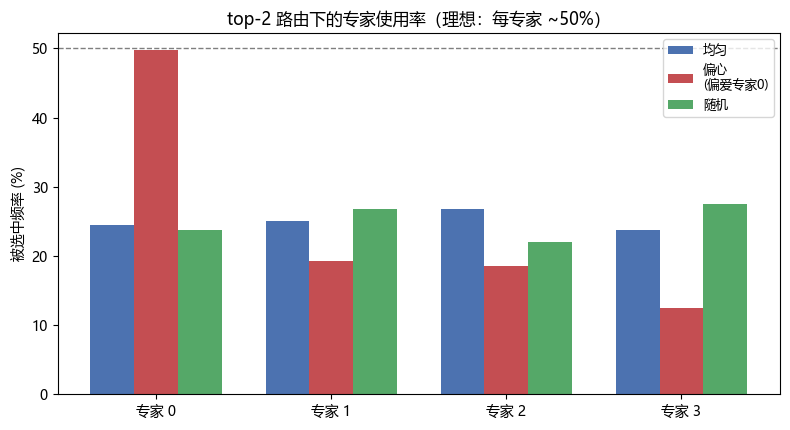

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 图1：3 个 router 的专家使用率（均衡度对比）
fig, ax = plt.subplots(figsize=(8, 4.4))
names = ['均匀', '偏心\n(偏爱专家0)', '随机']
usages = []
for name, Wg_, b_ in [('均匀', Wg_u, b_u), ('偏心', Wg_b, b_b), ('随机', Wg_r, b_r)]:
    s = router_gate_bias(XB, Wg_, b_)
    idx = np.argsort(-s, axis=1)[:, :2]
    load = np.array([(idx == i).sum() for i in range(N)])
    usages.append(100 * load / load.sum())
xx = np.arange(N); w = 0.25
colors = ['#4C72B0', '#C44E52', '#55A868']
for j, (name, u) in enumerate(zip(names, usages)):
    ax.bar(xx + (j - 1) * w, u, w, label=name, color=colors[j])
ax.set_xticks(xx); ax.set_xticklabels([f'专家 {i}' for i in range(N)])
ax.set_ylabel('被选中频率 (%)'); ax.legend(fontsize=9)
ax.set_title('top-2 路由下的专家使用率（理想：每专家 ~50%）', fontsize=12)
ax.axhline(50, color='k', ls='--', lw=1, alpha=0.5)
plt.tight_layout(); plt.show()


## 3. 真实工程对照（minLLM + DeepSeek）

| 环节 | 本讲 | minLLM `MOEFeedForward`（L148-181） | 生产（DeepSeek-V3） |
|---|---|---|---|
| 路由 | 手搓 softmax + topk | `gate = Linear(hidden, num_experts)` + `F.topk(k)` | 细粒度专家 + 共享专家 |
| 归一化 | top-k 权重归一化 | `norm_topk_prob`（k>1 归一化；k=1 straight-through） | 同 |
| 聚合 | 逐专家 index_add | `y.index_add_(0, token_idx, expert(x)*weight)` | 同（GPU 高效实现） |
| 负载均衡 | 手搓 aux_loss | `aux_loss = (load*scores.mean(0)).sum()*N*coef` | 同 + 专家级平衡 |
| 容量 | 4 专家 top-2 | `num_experts` / `num_experts_per_tok` 配置 | 256 专家 top-8 |

**MoE 的代价**：显存随专家数线性涨（全部专家都要驻留），推理用 expert parallelism；路由不平衡会浪费专家容量——所以 aux_loss 是标配。MiniMind 提供 `use_moe` 开关：同一个模型可以一键切成 MoE 版本（隐藏 FFN，加路由）。


## 总结

- **MoE = N 个专家 + Router 稀疏路由**：$y=\sum_{i\in\mathrm{topk}} \hat g_i E_i(x)$，每个 token 只算 top-k。
- 数值验证：MoE 前向与手动逐专家加权完全一致（<1e-10）。
- **负载均衡 aux_loss** 惩罚偏心的 router（实验：均匀 router aux_loss 最低），防止专家浪费。
- minLLM 的 `MOEFeedForward` 与本讲逐行对应；DeepSeek-V3 用 256 专家 + 细粒度/共享专家。
